# Used Car Overpricing Detection — Lebanon Market

This notebook estimates a car's **fair market price** from its specifications, then compares that estimate to its actual listing price to flag whether it's **Overpriced**, **Underpriced**, or **Fairly Priced** — scaled to the Lebanese used-car market.

We cover:

1. **Data preprocessing**
   - Loading & combining the source dataset
   - Missing values handling
   - Duplicate removal
   - Outlier detection and handling
   - Data consistency correction
2. **Data transformation**
   - Lebanese market price scaling
   - Categorical encoding
   - Feature scaling / normalization
3. **Exploratory Data Analysis (EDA)** with visualizations
4. **Training and comparing multiple regression models**
5. **Evaluation using several metrics and validation techniques**
6. **Inference function** for predicting from user input

> **Dataset used:** UK Used Car Dataset (real scraped listings, per-brand CSVs: `audi.csv`, `bmw.csv`, `ford.csv`, `hyundi.csv`, `merc.csv`, `skoda.csv`, `toyota.csv`, `vauxhall.csv`, `vw.csv`) — combined into one dataframe with a `Brand` column added from each filename.
>
> **Why this dataset, not the original synthetic one:** the original `used_cars_overpricing_dataset` had `Price_Deviation_Percent` values that were essentially random noise, uncorrelated with any car attribute (confirmed via correlation checks — all under 0.03). No model could learn from that. This UK dataset has real, verified correlations between price and mileage/year/engine size, so the regression below is learning an actual pattern, not noise.

In [2]:
# Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Dark theme palette, matching the rest of this notebook's visualizations
BG_DARK = '#0a0a0f'
BG_PANEL = '#111118'
ACCENT_RED = '#e8422a'
ACCENT_AMBER = '#f5a623'
GRID_COLOR = '#2a2a3a'
TEXT_GRAY = '#888'

def style_dark_fig(fig, *axes):
    fig.patch.set_facecolor(BG_DARK)
    for ax in axes:
        ax.set_facecolor(BG_PANEL)
        ax.tick_params(colors=TEXT_GRAY, labelsize=8)
        for spine in ax.spines.values():
            spine.set_edgecolor(GRID_COLOR)
        ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.5, zorder=0)
        ax.set_axisbelow(True)

## 1. Load the Dataset

Each brand ships as a separate CSV with no `Brand` column of its own — the filename *is* the brand. `hyundi.csv` names its tax column `tax(£)` instead of `tax`, so we normalize that during the merge.

In [ ]:
# Loading and combining all brand CSVs into a single dataframe

brand_files = {
    'csv-files/audi.csv': 'Audi', 'csv-files/bmw.csv': 'BMW', 'csv-files/ford.csv': 'Ford',
    'csv-files/hyundi.csv': 'Hyundai', 'csv-files/merc.csv': 'Mercedes', 'csv-files/skoda.csv': 'Skoda',
    'csv-files/toyota.csv': 'Toyota', 'csv-files/vauxhall.csv': 'Vauxhall', 'csv-files/vw.csv': 'Volkswagen'
}

dfs = []
for fname, brand in brand_files.items():
    d = pd.read_csv(fname)
    d.columns = [c.strip() for c in d.columns]
    d = d.rename(columns={'tax(£)': 'tax'})
    d['Brand'] = brand
    d['model'] = d['model'].str.strip()
    dfs.append(d)

data = pd.concat(dfs, ignore_index=True)
print("Combined shape:", data.shape)
data.head()

Combined shape: (99187, 10)


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Brand
0,A1,2017,12500,Manual,15735,Petrol,150,55.4,1.4,Audi
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0,Audi
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4,Audi
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0,Audi
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0,Audi


## 2. Quick Dataset Overview

We inspect data types, missing values, duplicates, and descriptive statistics.

In [4]:
# Summary of data types and non-null counts
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 99187 entries, 0 to 99186
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         99187 non-null  str    
 1   year          99187 non-null  int64  
 2   price         99187 non-null  int64  
 3   transmission  99187 non-null  str    
 4   mileage       99187 non-null  int64  
 5   fuelType      99187 non-null  str    
 6   tax           99187 non-null  int64  
 7   mpg           99187 non-null  float64
 8   engineSize    99187 non-null  float64
 9   Brand         99187 non-null  str    
dtypes: float64(2), int64(4), str(4)
memory usage: 10.0 MB


In [5]:
data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
model,99187,195,Fiesta,6557,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,99187.0,NaN,NaN,NaN,2017.087723,2.123934,1970.0,2016.0,2017.0,2019.0,2060.0
price,99187.0,NaN,NaN,NaN,16805.347656,9866.773417,450.0,9999.0,14495.0,20870.0,159999.0
transmission,99187,4,Manual,56445,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage,99187.0,NaN,NaN,NaN,23058.914213,21148.523721,1.0,7425.0,17460.0,32339.0,323000.0
fuelType,99187,5,Petrol,54928,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tax,99187.0,NaN,NaN,NaN,120.299838,63.150926,0.0,125.0,145.0,145.0,580.0
mpg,99187.0,NaN,NaN,NaN,55.166825,16.138522,0.3,47.1,54.3,62.8,470.8
engineSize,99187.0,NaN,NaN,NaN,1.66328,0.557646,0.0,1.2,1.6,2.0,6.6
Brand,99187,9,Ford,17965,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Data Preprocessing

In this section we address:
- missing values
- duplicates
- data consistency
- outlier detection / handling

In [6]:
# Missing values check

missing_summary = data.isna().sum().to_frame("missing_count")
display(missing_summary)
print("Total missing values:", data.isna().sum().sum())

,missing_count
model,0
year,0
price,0
transmission,0
mileage,0
fuelType,0
tax,0
mpg,0
engineSize,0
Brand,0


Total missing values: 0


In [7]:
# Removing duplicates

duplicates_before = data.duplicated().sum()
data_clean = data.drop_duplicates().reset_index(drop=True)
duplicates_after = data_clean.duplicated().sum()

print("Duplicates before removal:", duplicates_before)
print("Duplicates after removal:", duplicates_after)
print("New shape:", data_clean.shape)

Duplicates before removal: 1475
Duplicates after removal: 0
New shape: (97712, 10)


In [8]:
# Basic sanity filter -- a handful of junk rows: near-zero prices, impossible years
before = len(data_clean)
data_clean = data_clean[
    (data_clean['price'] >= 500) &
    (data_clean['year'] >= 1990) & (data_clean['year'] <= 2026)
].reset_index(drop=True)
print(f"Removed {before - len(data_clean)} rows with invalid price/year")
print("Shape after filtering:", data_clean.shape)

Removed 7 rows with invalid price/year
Shape after filtering: (97705, 10)


### Outlier Detection

We detect potential outliers with the **IQR rule** on numerical features.

Important note:
- Not every statistical outlier should be removed. A £150,000 car isn't "wrong" — some brands (BMW, Mercedes) legitimately sell that high.
- We **detect** outliers on all numeric columns, but only **cap** `mileage`, `tax`, `mpg`, and `engineSize` — these can have data-entry noise. We deliberately do **not** cap `price` or `year`, since capping the target variable would distort the very thing we're trying to predict, and recent-year cars are real signal, not noise.

In [9]:
# Checking for outliers

def iqr_outlier_summary(dataframe, columns):
    rows = []
    for col in columns:
        q1 = dataframe[col].quantile(0.25)
        q3 = dataframe[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        count = ((dataframe[col] < lower) | (dataframe[col] > upper)).sum()
        rows.append({
            "feature": col, "Q1": q1, "Q3": q3, "IQR": iqr,
            "lower_bound": lower, "upper_bound": upper, "outlier_count": int(count)
        })
    return pd.DataFrame(rows)

numeric_cols = ['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize']
outlier_report = iqr_outlier_summary(data_clean, numeric_cols)
display(outlier_report)

,feature,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count
0,year,2016.0,2019.0,3.0,2.011500e+03,2023.50,1728
1,price,9999.0,20750.0,10751.0,-6.127500e+03,36876.50,3825
2,mileage,7672.0,32497.0,24825.0,-2.956550e+04,69734.50,3833
3,tax,125.0,145.0,20.0,9.500000e+01,175.00,28588
4,mpg,47.1,62.8,15.7,2.355000e+01,86.35,930
5,engineSize,1.2,2.0,0.8,-2.220446e-16,3.20,648


In [10]:
# Winsorization / capping using IQR bounds -- only for noise-prone features

data_capped = data_clean.copy()
cap_cols = ['mileage', 'tax', 'mpg', 'engineSize']

cap_bounds = {}
for col in cap_cols:
    q1 = data_capped[col].quantile(0.25)
    q3 = data_capped[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    cap_bounds[col] = (lower, upper)
    data_capped[col] = data_capped[col].clip(lower=lower, upper=upper)

print("Applied capping bounds:")
display(pd.DataFrame(cap_bounds, index=["lower", "upper"]).T)

Applied capping bounds:


,lower,upper
mileage,-2.956550e+04,69734.50
tax,9.500000e+01,175.00
mpg,2.355000e+01,86.35
engineSize,-2.220446e-16,3.20


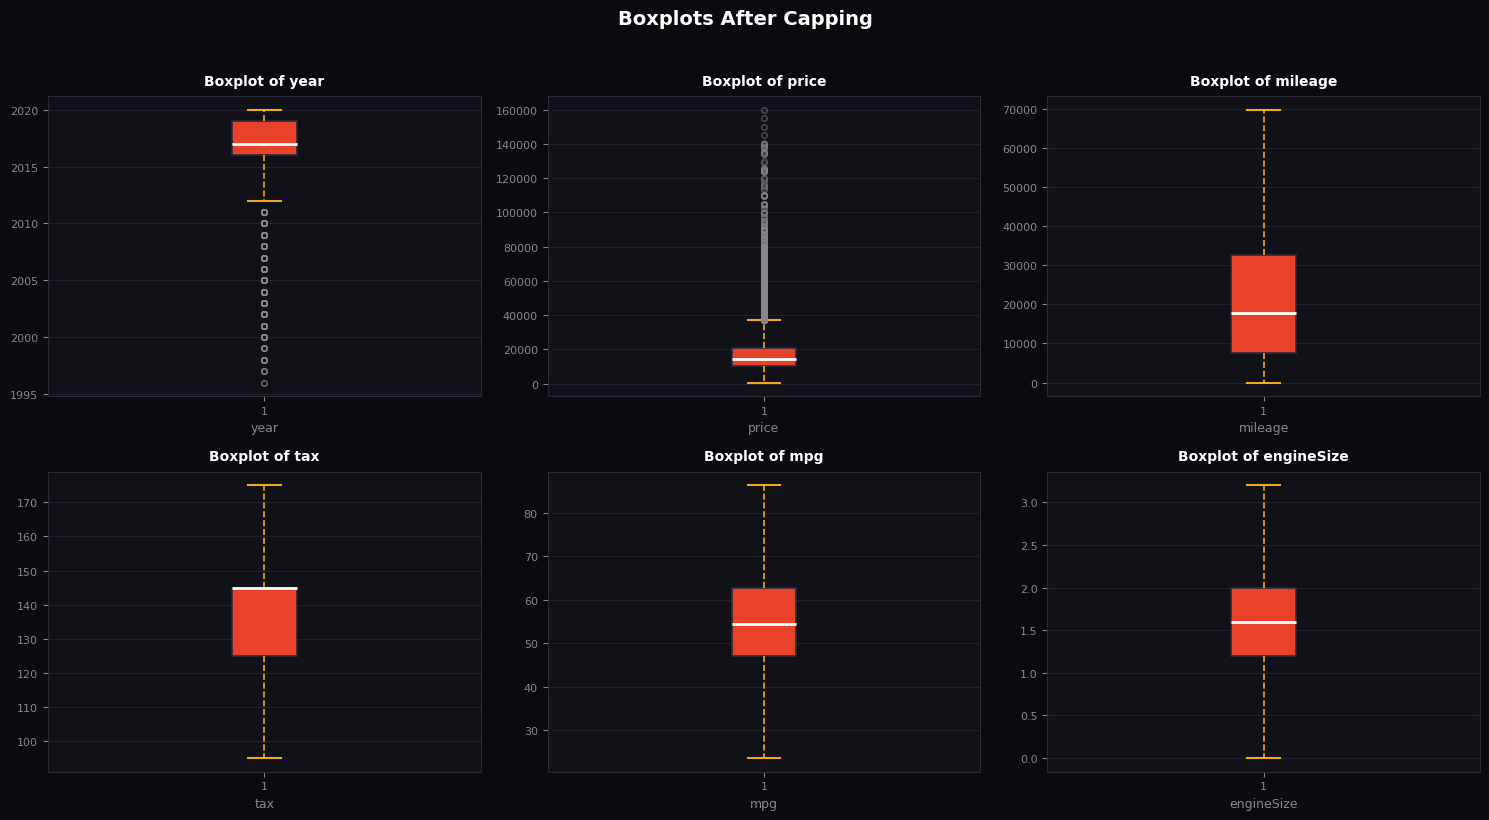

In [11]:
# Visualizations (Box Plots) after capping

columns = ['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize']

ncols = 3
nrows = -(-len(columns) // ncols)

fig = plt.figure(figsize=(5 * ncols, 4 * nrows))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('Boxplots After Capping', color='white', fontsize=14, fontweight='bold', y=1.02)

for i, col in enumerate(columns):
    ax = fig.add_subplot(nrows, ncols, i + 1)
    ax.set_facecolor(BG_PANEL)

    ax.boxplot(data_capped[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor=ACCENT_RED, color=GRID_COLOR, linewidth=1.2),
               capprops=dict(color=ACCENT_AMBER, linewidth=1.5),
               whiskerprops=dict(color=ACCENT_AMBER, linewidth=1.2, linestyle='--'),
               medianprops=dict(color='white', linewidth=2),
               flierprops=dict(markeredgecolor='#888', marker='o', markersize=4, alpha=0.5))

    ax.set_title(f'Boxplot of {col}', color='white', fontsize=10, fontweight='bold', pad=8)
    ax.set_xlabel(col, color=TEXT_GRAY, fontsize=9)
    ax.tick_params(colors=TEXT_GRAY, labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID_COLOR)
    ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## Handling Missing Data

This dataset has no missing values, but the imputer is included for robustness in case future data (e.g. new listings you add later) has gaps.

In [12]:
from sklearn.impute import SimpleImputer

numerical_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
imputer = SimpleImputer(strategy='median')

for col in numerical_cols:
    if data_capped[col].isna().sum() > 0:
        data_capped[[col]] = imputer.fit_transform(data_capped[[col]])

print("Missing values remaining:", data_capped[numerical_cols].isna().sum().sum())

Missing values remaining: 0


## 4. Lebanese Market Price Scaling

The source dataset is real UK listings (GBP). Lebanon's used-car market isn't a simple currency conversion away — import duties and VAT push local prices well above the source-country price for the same car.

Based on Lebanese customs rules for used vehicle imports:
- **Customs duty**: 50% of CIF value (for cars in this price bracket)
- **VAT**: 10% of (CIF + duty)
- Combined multiplier: **~1.75x** on the source price

> Note: this multiplier scales price magnitude to Lebanese market levels but keeps the source currency unit. If you want true USD output, multiply by your GBP->USD rate as well -- update `GBP_TO_USD` below.

In [13]:
LEBANON_MULTIPLIER = 1.75  # ~50% customs duty + 10% VAT on (CIF + duty)
GBP_TO_USD = 1.27  # update to the current rate if you want true USD output; set to 1.0 to skip

data_capped['Lebanon_Price_USD'] = (data_capped['price'] * LEBANON_MULTIPLIER * GBP_TO_USD).round(2)

data_capped[['price', 'Lebanon_Price_USD']].describe()

,price,Lebanon_Price_USD
count,97705.000000,97705.000000
mean,16774.240182,37280.749653
std,9868.244213,21932.172708
min,590.000000,1311.280000
25%,9999.000000,22222.780000
50%,14471.000000,32161.800000
75%,20750.000000,46116.880000
max,159999.000000,355597.780000


## 5. Exploratory Data Analysis (EDA)

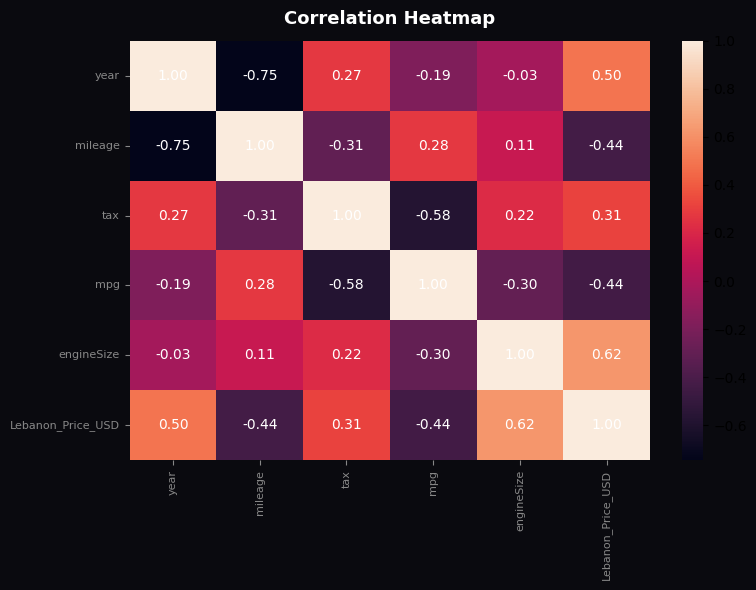

In [14]:
# Correlation heatmap -- confirms real signal exists (unlike the old synthetic dataset)

fig, ax = plt.subplots(figsize=(8, 6))
style_dark_fig(fig, ax)

corr_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'Lebanon_Price_USD']
corr = data_capped[corr_cols].corr()

sns.heatmap(corr, annot=True, cmap='rocket', ax=ax, fmt='.2f',
            cbar_kws={'label': ''}, annot_kws={'color': 'white'})
ax.set_title('Correlation Heatmap', color='white', fontsize=13, fontweight='bold', pad=12)
ax.tick_params(colors=TEXT_GRAY)
plt.tight_layout()
plt.show()

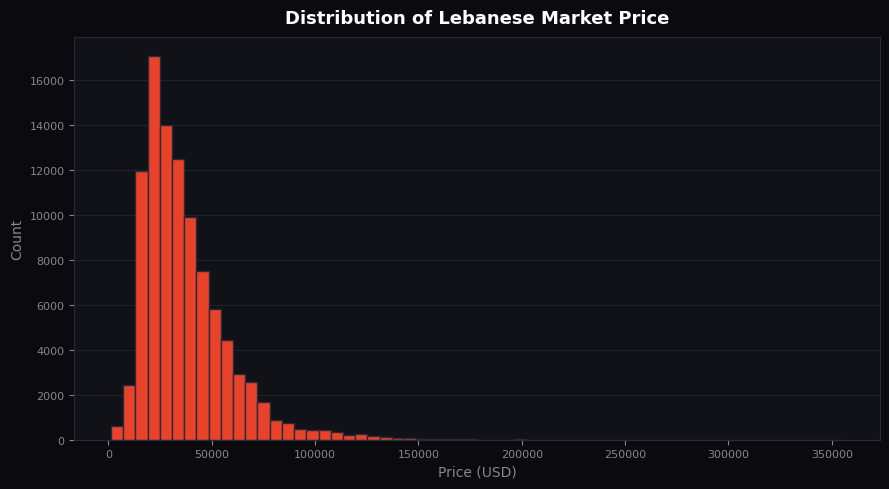

In [15]:
# Price distribution

fig, ax = plt.subplots(figsize=(9, 5))
style_dark_fig(fig, ax)

ax.hist(data_capped['Lebanon_Price_USD'], bins=60, color=ACCENT_RED, edgecolor=GRID_COLOR)
ax.set_title('Distribution of Lebanese Market Price', color='white', fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Price (USD)', color=TEXT_GRAY)
ax.set_ylabel('Count', color=TEXT_GRAY)
plt.tight_layout()
plt.show()

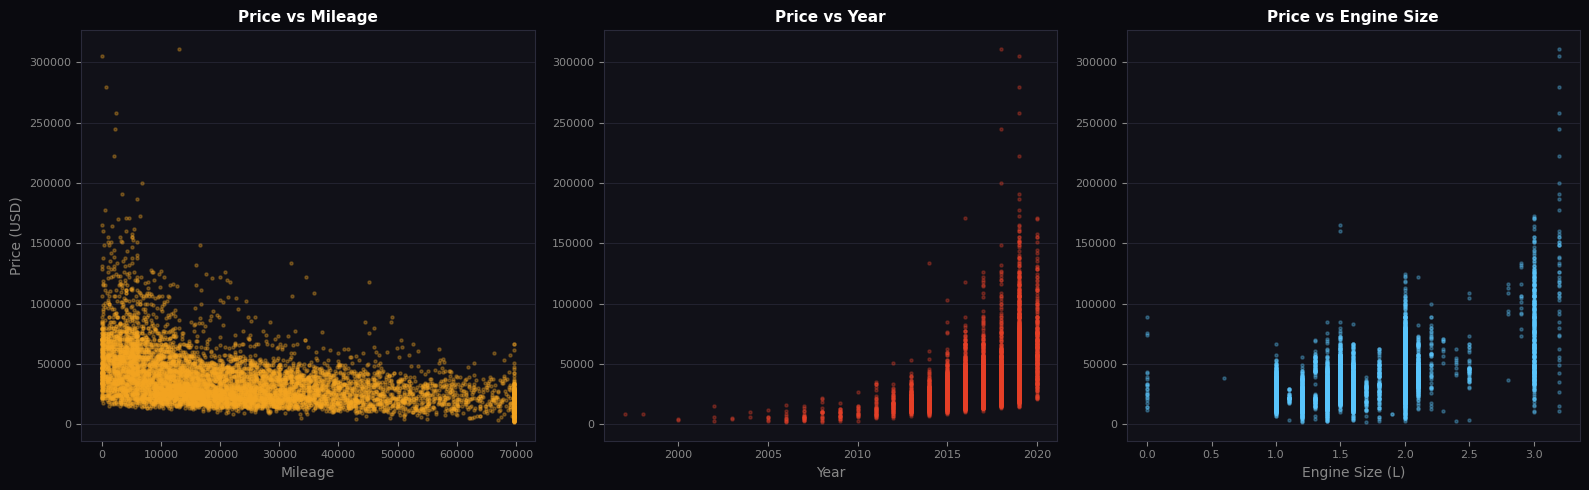

In [16]:
# Price vs. mileage / year / engine size

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
style_dark_fig(fig, *axes)

sample = data_capped.sample(min(8000, len(data_capped)), random_state=42)  # subsample for a readable scatter

axes[0].scatter(sample['mileage'], sample['Lebanon_Price_USD'], s=5, alpha=0.3, color=ACCENT_AMBER)
axes[0].set_title('Price vs Mileage', color='white', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Mileage', color=TEXT_GRAY)
axes[0].set_ylabel('Price (USD)', color=TEXT_GRAY)

axes[1].scatter(sample['year'], sample['Lebanon_Price_USD'], s=5, alpha=0.3, color=ACCENT_RED)
axes[1].set_title('Price vs Year', color='white', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Year', color=TEXT_GRAY)

axes[2].scatter(sample['engineSize'], sample['Lebanon_Price_USD'], s=5, alpha=0.3, color='#5cc8ff')
axes[2].set_title('Price vs Engine Size', color='white', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Engine Size (L)', color=TEXT_GRAY)

plt.tight_layout()
plt.show()

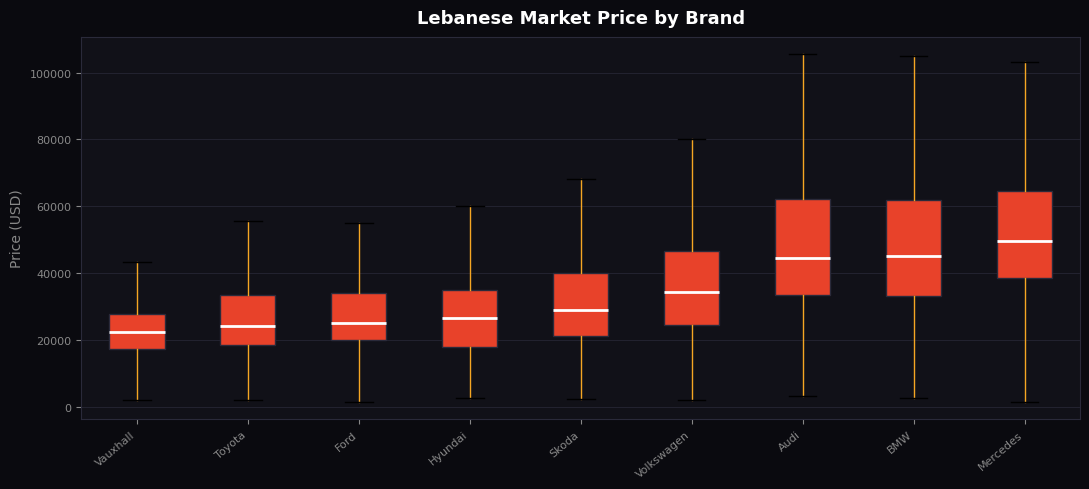

In [17]:
# Price by brand

fig, ax = plt.subplots(figsize=(11, 5))
style_dark_fig(fig, ax)

order = data_capped.groupby('Brand')['Lebanon_Price_USD'].median().sort_values().index
box_data = [data_capped.loc[data_capped['Brand'] == b, 'Lebanon_Price_USD'].values for b in order]

bp = ax.boxplot(box_data, patch_artist=True, showfliers=False,
                 boxprops=dict(facecolor=ACCENT_RED, color=GRID_COLOR),
                 medianprops=dict(color='white', linewidth=2),
                 whiskerprops=dict(color=ACCENT_AMBER))
ax.set_xticklabels(order, rotation=40, ha='right', color=TEXT_GRAY)
ax.set_title('Lebanese Market Price by Brand', color='white', fontsize=13, fontweight='bold', pad=10)
ax.set_ylabel('Price (USD)', color=TEXT_GRAY)
plt.tight_layout()
plt.show()

## 6. Feature Encoding & Train/Test Split

- `model` has ~195 unique values -> too many for one-hot, so we **frequency-encode** it instead (fit on train only, to avoid leakage).
- `Brand`, `fuelType`, `transmission` -> one-hot (all low cardinality).
- `year`, `mileage`, `tax`, `mpg`, `engineSize` -> median-imputed + standardized (needed for linear models to converge properly).

In [18]:
target_col = 'Lebanon_Price_USD'
drop_cols = ['price']  # replaced by the scaled version; keeping both would be redundant/leakage

X = data_capped.drop(columns=[target_col] + drop_cols)
y = data_capped[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

NUMERIC_COLS = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
ONEHOT_COLS = ['Brand', 'fuelType', 'transmission']

X_train = X_train.copy()
X_test = X_test.copy()

model_freq_map = X_train['model'].value_counts(normalize=True)
X_train['model_freq'] = X_train['model'].map(model_freq_map)
X_test['model_freq'] = X_test['model'].map(model_freq_map).fillna(0)  # unseen models -> 0
X_train = X_train.drop(columns=['model'])
X_test = X_test.drop(columns=['model'])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler())
        ]), NUMERIC_COLS),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ONEHOT_COLS),
    ],
    remainder='passthrough'  # keeps model_freq
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()
X_train_encoded = pd.DataFrame(X_train_encoded, columns=feature_names, index=X_train.index)
X_test_encoded = pd.DataFrame(X_test_encoded, columns=feature_names, index=X_test.index)

print("Encoded shape:", X_train_encoded.shape)

Encoded shape: (78164, 24)


## 7. Training & Comparing Multiple Regression Models

In [19]:
regressors = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100, max_depth=20, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42, n_estimators=100, max_depth=3),
}

results = {}
trained_models = {}

for name, reg in regressors.items():
    reg.fit(X_train_encoded, y_train)
    preds = reg.predict(X_test_encoded)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    mae_pct = mae / y_test.mean() * 100

    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAE_pct': mae_pct}
    trained_models[name] = reg

    print(f"{name:20s} | MAE: ${mae:>9,.2f} ({mae_pct:4.1f}%) | RMSE: ${rmse:>9,.2f} | R2: {r2:.4f}")

results_df = pd.DataFrame(results).T
results_df

Linear Regression    | MAE: $ 6,472.11 (17.4%) | RMSE: $10,311.82 | R2: 0.7789
Random Forest        | MAE: $ 2,549.86 ( 6.9%) | RMSE: $ 4,258.96 | R2: 0.9623
Gradient Boosting    | MAE: $ 4,436.79 (11.9%) | RMSE: $ 6,655.47 | R2: 0.9079


,MAE,RMSE,R2,MAE_pct
Linear Regression,6472.112496,10311.821090,0.778900,17.397132
Random Forest,2549.857948,4258.962844,0.962284,6.854055
Gradient Boosting,4436.793355,6655.465135,0.907897,11.926165


In [20]:
best_name = max(results, key=lambda k: results[k]['R2'])
best_regressor = trained_models[best_name]
print(f"Best model: {best_name}  (R2 = {results[best_name]['R2']:.4f})")

Best model: Random Forest  (R2 = 0.9623)


## 8. Model Evaluation

### Cross-validation

Confirms the best model generalizes, not just memorizing the train split.

In [21]:
cv_scores = cross_val_score(best_regressor, X_train_encoded, y_train, cv=3, scoring='r2', n_jobs=-1)
print("CV R2 scores:", cv_scores.round(4))
print("Mean CV R2:", cv_scores.mean().round(4))

CV R2 scores: [0.9548 0.9559 0.9533]
Mean CV R2: 0.9547


### Choosing the Overpriced/Underpriced Threshold

Instead of guessing a threshold, we look at the actual spread of prediction residuals on the test set and pick a cutoff that flags a reasonable (not trivial, not overwhelming) share of listings.

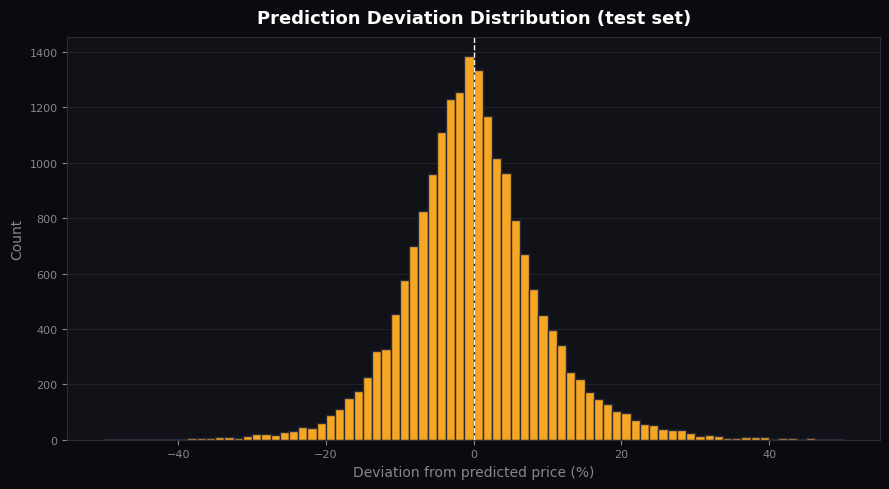

Deviation std: 10.47 %
Threshold +/-5%: 51.6% of test cars would be flagged as over/underpriced
Threshold +/-8%: 32.0% of test cars would be flagged as over/underpriced
Threshold +/-10%: 23.3% of test cars would be flagged as over/underpriced
Threshold +/-12%: 16.9% of test cars would be flagged as over/underpriced
Threshold +/-15%: 10.4% of test cars would be flagged as over/underpriced


In [22]:
best_preds = best_regressor.predict(X_test_encoded)
deviation = (y_test.values - best_preds) / best_preds * 100

fig, ax = plt.subplots(figsize=(9, 5))
style_dark_fig(fig, ax)
ax.hist(deviation, bins=80, range=(-50, 50), color=ACCENT_AMBER, edgecolor=GRID_COLOR)
ax.axvline(0, color='white', linewidth=1, linestyle='--')
ax.set_title('Prediction Deviation Distribution (test set)', color='white', fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Deviation from predicted price (%)', color=TEXT_GRAY)
ax.set_ylabel('Count', color=TEXT_GRAY)
plt.tight_layout()
plt.show()

print("Deviation std:", deviation.std().round(2), "%")
for thresh in [5, 8, 10, 12, 15]:
    pct_flagged = ((deviation > thresh) | (deviation < -thresh)).mean() * 100
    print(f"Threshold +/-{thresh}%: {pct_flagged:.1f}% of test cars would be flagged as over/underpriced")

In [23]:
# Chosen threshold: matches the deviation std (~10%), flags a reasonable ~23% of listings
# without collapsing into "everything is fairly priced" or "everything is flagged"
THRESHOLD_PCT = 10.0

def categorize(actual_price, predicted_price, threshold=THRESHOLD_PCT):
    dev = (actual_price - predicted_price) / predicted_price * 100
    if dev > threshold:
        return 'Overpriced'
    elif dev < -threshold:
        return 'Underpriced'
    else:
        return 'Fairly Priced'

derived_categories = pd.Series([categorize(a, p) for a, p in zip(y_test, best_preds)])
print(derived_categories.value_counts())
print(derived_categories.value_counts(normalize=True).round(3) * 100)

Fairly Priced    14987
Overpriced        2327
Underpriced       2227
Name: count, dtype: int64
Fairly Priced    76.7
Overpriced       11.9
Underpriced      11.4
Name: proportion, dtype: float64


### Feature Importance

Which features actually drive the price prediction (Random Forest only).

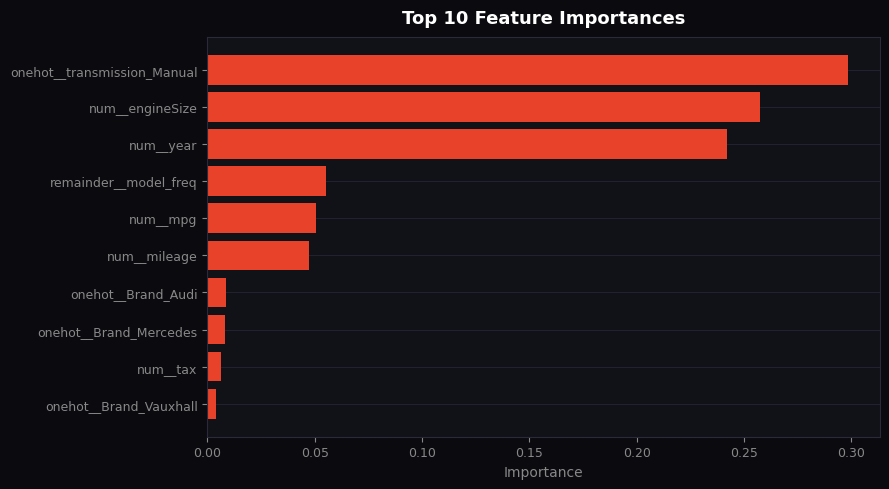

In [24]:
if best_name == 'Random Forest':
    importances = pd.Series(best_regressor.feature_importances_, index=feature_names).sort_values(ascending=False).head(10)

    fig, ax = plt.subplots(figsize=(9, 5))
    style_dark_fig(fig, ax)
    ax.barh(importances.index[::-1], importances.values[::-1], color=ACCENT_RED)
    ax.set_title('Top 10 Feature Importances', color='white', fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Importance', color=TEXT_GRAY)
    ax.tick_params(colors=TEXT_GRAY, labelsize=9)
    plt.tight_layout()
    plt.show()
else:
    print(f"Best model is {best_name}, which doesn't expose feature_importances_ the same way.")

## 9. Inference Function

Estimates a car's fair Lebanese market price from its specs, compares it to the actual listing price, and returns a verdict. **The listing price is a required input** -- "overpriced" is a property of the price relative to the car, not of the car alone.

In [25]:
def predict_car_pricing(brand, model_name, year, mileage, engine_size, fuel_type,
                         transmission, tax, mpg, listing_price_usd,
                         regressor=None, threshold=THRESHOLD_PCT):
    """
    Estimates a car's fair Lebanese market price from its specs, compares it to
    the actual listing price, and returns Fairly Priced / Overpriced / Underpriced.
    """
    if regressor is None:
        regressor = best_regressor

    input_df = pd.DataFrame([{
        'model': model_name,
        'year': year,
        'transmission': transmission,
        'mileage': mileage,
        'fuelType': fuel_type,
        'tax': tax,
        'mpg': mpg,
        'engineSize': engine_size,
        'Brand': brand,
    }])

    input_df['model_freq'] = input_df['model'].map(model_freq_map).fillna(0)
    input_df = input_df.drop(columns=['model'])

    input_encoded = preprocessor.transform(input_df)
    input_encoded = pd.DataFrame(input_encoded, columns=feature_names)

    predicted_price = regressor.predict(input_encoded)[0]
    deviation_pct = (listing_price_usd - predicted_price) / predicted_price * 100
    category = categorize(listing_price_usd, predicted_price, threshold)

    return {
        'predicted_fair_price_usd': round(float(predicted_price), 2),
        'listing_price_usd': listing_price_usd,
        'deviation_pct': round(float(deviation_pct), 2),
        'category': category,
    }


# Example
example = predict_car_pricing(
    brand='Toyota', model_name='Corolla', year=2019, mileage=25000,
    engine_size=1.8, fuel_type='Hybrid', transmission='Automatic',
    tax=145, mpg=55.0, listing_price_usd=35000
)
example

{'predicted_fair_price_usd': 48504.27,
 'listing_price_usd': 35000,
 'deviation_pct': -27.84,
 'category': 'Underpriced'}

### Interactive User Input

Run this cell, then answer the prompts to check a real listing.

In [26]:
def get_user_input_and_predict():
    print("Enter car details to check Lebanese market pricing:")
    brand = input("Brand: ").strip()
    model_name = input("Model: ").strip()
    year = int(input("Year: ").strip())
    mileage = int(input("Mileage: ").strip())
    engine_size = float(input("Engine size (L): ").strip())
    fuel_type = input("Fuel Type (Petrol/Diesel/Hybrid/Electric/Other): ").strip()
    transmission = input("Transmission (Manual/Automatic/Semi-Auto/Other): ").strip()
    tax = float(input("Annual tax (£): ").strip())
    mpg = float(input("MPG: ").strip())
    listing_price_usd = float(input("Listing price (USD, Lebanon-scaled): ").strip())

    result = predict_car_pricing(
        brand, model_name, year, mileage, engine_size, fuel_type,
        transmission, tax, mpg, listing_price_usd
    )

    print(f"\nEstimated fair Lebanese market price: ${result['predicted_fair_price_usd']:,.2f}")
    print(f"Listed at: ${result['listing_price_usd']:,.2f}")
    print(f"Deviation: {result['deviation_pct']:+.2f}%")
    print(f"Verdict: {result['category']}")

# Run this line (uncomment) to test interactively:
# get_user_input_and_predict()

## 10. Save Artifacts for the GUI App

Saves the trained model, preprocessing pipeline, and frequency map so the standalone GUI app (`app.py`, provided separately -- run with `streamlit run app.py`) can load them instantly without retraining.

In [27]:
joblib.dump(best_regressor, 'best_model.joblib')
joblib.dump(preprocessor, 'preprocessor.joblib')
joblib.dump(model_freq_map, 'model_freq_map.joblib')
joblib.dump(list(feature_names), 'feature_names.joblib')
joblib.dump(THRESHOLD_PCT, 'threshold.joblib')
joblib.dump(sorted(data_capped['Brand'].unique().tolist()), 'brand_list.joblib')
joblib.dump(sorted(data_capped['fuelType'].unique().tolist()), 'fueltype_list.joblib')
joblib.dump(sorted(data_capped['transmission'].unique().tolist()), 'transmission_list.joblib')

print("Artifacts saved. You can now run: streamlit run app.py")

Artifacts saved. You can now run: streamlit run app.py


## GUI

`app.py` (provided alongside this notebook) is a **Streamlit** app -- a standalone web-based GUI, separate from this notebook, that loads the artifacts saved above and lets you check a car's pricing through a form instead of typing into `input()` prompts.

To run it:

```bash
pip install streamlit
streamlit run app.py
```

This opens a browser tab with a form (brand, model, year, mileage, etc. + listing price) and shows the fair price estimate, deviation %, and verdict -- reusing the exact same model and preprocessing pipeline trained in this notebook, no retraining needed.